--- DATOS OFICIALES DE BIKESHARE (WASHINGTON D.C.) ---
Total de horas analizadas: 8645 registros.
Total de bicicletas rentadas (2011-2012): 1243103 bicicletas.



interactive(children=(IntSlider(value=40, description='Barras Hist.:', min=10, step=5), Dropdown(description='…

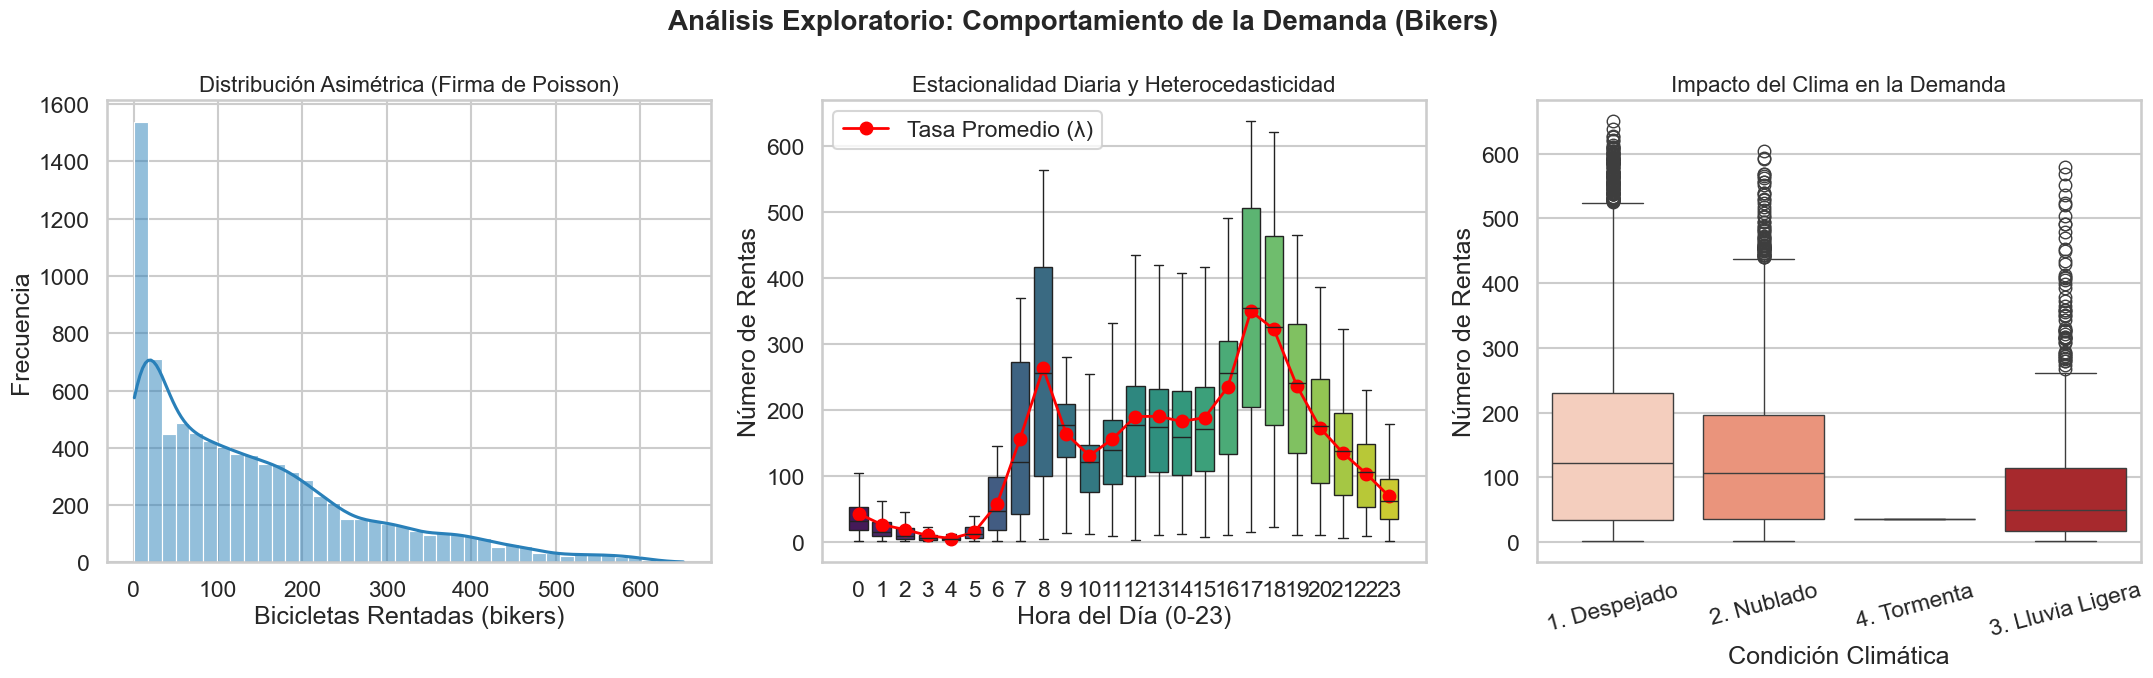

Hora del Día,Media (Promedio de bicis),Varianza (Dispersión/Caos)
3,10.060000,129.960000
4,5.390000,11.640000
8,262.990000,25999.370000
12,190.100000,11478.100000
17,349.680000,27999.600000
18,322.270000,25803.060000


In [4]:
# importamos todo las librerias necesarias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact
from ISLP import load_data
from IPython.display import display
import warnings

# ignoro los warnings rojos q salen aveces y molestan
warnings.filterwarnings('ignore')

# cargo los datos y me quedo con las columnas que importan
df_raw = load_data('Bikeshare')
df = df_raw[['bikers', 'mnth', 'hr', 'weathersit', 'temp', 'workingday']].copy()

# pasamos estas a categoricas para poder agrupar mejor
for col in ['mnth', 'hr', 'weathersit', 'workingday']:
    df[col] = df[col].astype('category')

# le pongo los nombres en español al clima para que se entienda en los graficos
clima_map = {
    'clear': '1. Despejado',
    'cloudy/misty': '2. Nublado',
    'light rain/snow': '3. Lluvia Ligera',
    'heavy rain/snow': '4. Tormenta'
}

if df['weathersit'].dtype.name == 'category' and isinstance(df['weathersit'].iloc[0], str):
    df['weathersit_label'] = df['weathersit'].map(clima_map)
else:
    df['weathersit_label'] = df['weathersit']

# Chequeamos que la data se lea bien
print("--- DATOS OFICIALES DE BIKESHARE (WASHINGTON D.C.) ---")
print(f"Total de horas analizadas: {len(df)} registros.")
print(f"Total de bicicletas rentadas (2011-2012): {df['bikers'].sum()} bicicletas.\n")

# armo la funcion para los graficos dinamicos
def graficar_eda_interactivo(bins, tema, paleta_cajas, color_histograma):
    sns.set_theme(style=tema)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # primer grafico 
    sns.histplot(df['bikers'], bins=bins, kde=True, color=color_histograma, ax=axes[0])
    axes[0].set_title('Distribución de Ciclistas (bikers)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Número de Rentas por Hora')
    axes[0].set_ylabel('Frecuencia')
    
    # segundo grafico 
    sns.boxplot(x='hr', y='bikers', data=df, palette=paleta_cajas, ax=axes[1])
    axes[1].set_title('Impacto de la Hora del Día', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Hora del Día (0-23)')
    axes[1].set_ylabel('Número de Rentas')
    
    # tercer grafico 
    sns.boxplot(x='weathersit_label', y='bikers', data=df, palette=paleta_cajas, ax=axes[2])
    axes[2].set_title('Impacto de la Situación Climática', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Situación Climática')
    axes[2].set_ylabel('Número de Rentas')
    axes[2].tick_params(axis='x', rotation=15)
    
    plt.tight_layout()
    plt.show()

interact(graficar_eda_interactivo,
         bins=widgets.IntSlider(value=40, min=10, max=100, step=5, description='Barras Hist.:'),
         tema=widgets.Dropdown(options=['whitegrid', 'darkgrid', 'ticks', 'white'], value='whitegrid', description='Fondo:'),
         paleta_cajas=widgets.Dropdown(options=['viridis', 'plasma', 'Set2', 'coolwarm', 'Reds'], value='viridis', description='Paleta Cajas:'),
         color_histograma=widgets.Dropdown(options=['skyblue', 'salmon', 'lightgreen', 'purple', 'gray'], value='skyblue', description='Color Hist.:'))



sns.set_theme(style="whitegrid", context="talk")
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Análisis Exploratorio: Comportamiento de la Demanda (Bikers)', fontsize=20, fontweight='bold')

# histo normal
sns.histplot(df['bikers'], bins=40, kde=True, color='#2980b9', ax=axes[0])
axes[0].set_title('Distribución Asimétrica (Firma de Poisson)', fontsize=16)
axes[0].set_xlabel('Bicicletas Rentadas (bikers)')
axes[0].set_ylabel('Frecuencia')

# cajas por hora y le agrego la linea roja del promedio
sns.boxplot(x='hr', y='bikers', data=df, palette='viridis', ax=axes[1], showfliers=False)
promedios_hora = df.groupby('hr')['bikers'].mean()
axes[1].plot(promedios_hora.index, promedios_hora.values, color='red', marker='o', linestyle='-', linewidth=2, label='Tasa Promedio (λ)')
axes[1].set_title('Estacionalidad Diaria y Heterocedasticidad', fontsize=16)
axes[1].set_xlabel('Hora del Día (0-23)')
axes[1].set_ylabel('Número de Rentas')
axes[1].legend()

# cajas por clima
sns.boxplot(x='weathersit_label', y='bikers', data=df, palette='Reds', ax=axes[2])
axes[2].set_title('Impacto del Clima en la Demanda', fontsize=16)
axes[2].set_xlabel('Condición Climática')
axes[2].set_ylabel('Número de Rentas')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# armo la tabla para mostrar q la varianza crece con la media, asi se jsutifica que se  usa poisson y no regresion lineal
tabla_poisson = df.groupby('hr')['bikers'].agg(['mean', 'var']).reset_index()
tabla_poisson.columns = ['Hora del Día', 'Media (Promedio de bicis)', 'Varianza (Dispersión/Caos)']
# agarro algunas horas para comparar la madrugada con las horas pico
horas_clave = [3, 4, 8, 12, 17, 18] 
tabla_resumen = tabla_poisson[tabla_poisson['Hora del Día'].isin(horas_clave)].copy()

display(tabla_resumen.round(2).style.hide(axis="index"))

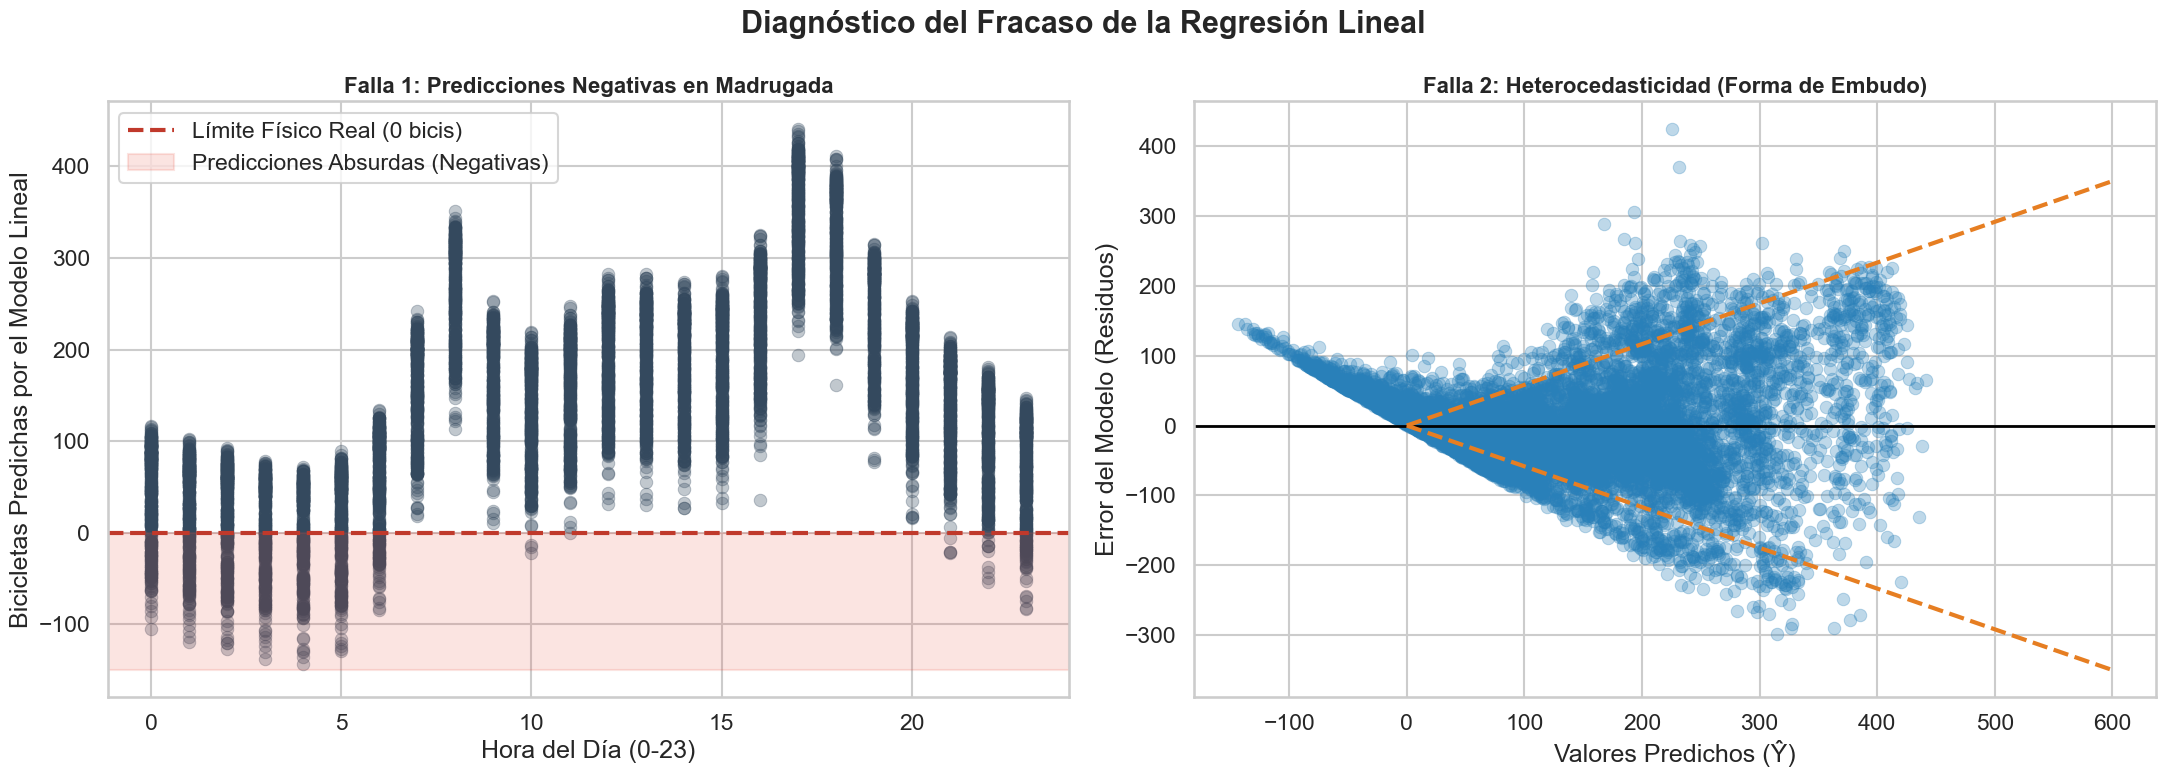


MUESTRAS ALEATORIAS DE FALLAS ESTRUCTURALES DEL MODELO LINEAL

1. FALLA DEL LÍMITE FÍSICO (MADRUGADA):
El modelo predice valores negativos al no tener un piso matemático.


bikers,hr,weathersit_label,temp,workingday,Prediccion_Lineal
7,5,1. Despejado,0.060000,1,-75.220000
7,5,3. Lluvia Ligera,0.340000,0,-64.390000
2,5,2. Nublado,0.260000,0,-64.780000
4,2,2. Nublado,0.340000,0,-42.800000
3,5,1. Despejado,0.140000,0,-70.760000



2. FALLA DE ADITIVIDAD (CLIMA ADVERSO + DÍA NO LABORAL):
OLS resta valores fijos por lluvia y por fin de semana, haciendo absurda la prediccion


bikers,hr,weathersit_label,temp,workingday,Prediccion_Lineal
5,4,3. Lluvia Ligera,0.340000,0,-77.160000
9,5,3. Lluvia Ligera,0.200000,0,-120.970000
14,3,3. Lluvia Ligera,0.300000,0,-77.680000
19,0,3. Lluvia Ligera,0.280000,0,-15.270000
13,22,3. Lluvia Ligera,0.140000,0,-53.990000



3. FALLA DE PENDIENTE CONSTANTE (FRÍO EXTREMO):
A temperaturas cercanas a cero (temp < 0.2), la línea recta castiga la demanda cruzando el cero


bikers,hr,weathersit_label,temp,workingday,Prediccion_Lineal
33,0,1. Despejado,0.160000,0,-43.480000
6,23,1. Despejado,0.120000,0,-22.930000
1,3,2. Nublado,0.140000,1,-82.540000
21,5,1. Despejado,0.140000,1,-23.030000
8,5,1. Despejado,0.140000,1,-52.940000



4. FALLA DE FLEXIBILIDAD (SUBESTIMACIÓN EN HORAS PICO):
A las 17:00-18:00 hrs la demanda aumenta drasticamente (> 600 bicis), pero la línea recta se queda corta.


bikers,Prediccion_Lineal,Error_Absoluto,hr,weathersit_label
625,399.060000,225.940000,17,1. Despejado
604,386.170000,217.830000,17,2. Nublado
607,383.090000,223.910000,18,1. Despejado
621,371.660000,249.340000,18,1. Despejado
601,417.800000,183.200000,17,1. Despejado


In [8]:
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import warnings
warnings.filterwarnings('ignore') 

# creamos el modelo de regresion lineal
formula = 'bikers ~ mnth + hr + weathersit + temp + workingday'
modelo_lineal = smf.ols(formula=formula, data=df).fit()

# ahora hacemos las predicciones y calcualmos los residuos
df_analisis = df.copy()
df_analisis['Prediccion_Lineal'] = modelo_lineal.predict(df_analisis)
df_analisis['Residuo_Lineal'] = df_analisis['bikers'] - df_analisis['Prediccion_Lineal']


sns.set_theme(style="whitegrid", context="talk")
fig, axes = plt.subplots(1, 2, figsize=(22, 8))
fig.suptitle('Diagnóstico del Fracaso de la Regresión Lineal', fontsize=22, fontweight='bold')

# grafico 1, las predicciones negativasdez
sns.scatterplot(x='hr', y='Prediccion_Lineal', data=df_analisis, 
                alpha=0.3, color='#34495e', ax=axes[0], edgecolor=None)

# Pintamos la linea en 0 que es el limite
axes[0].axhline(0, color='#c0392b', linestyle='--', linewidth=3, label='Límite Físico Real (0 bicis)')
# y sobreamos toda el area negativa  no tiene sentido
axes[0].axhspan(-150, 0, color='#e74c3c', alpha=0.15, label='Predicciones Absurdas (Negativas)')

axes[0].set_title('Falla 1: Predicciones Negativas en Madrugada', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Hora del Día (0-23)')
axes[0].set_ylabel('Bicicletas Predichas por el Modelo Lineal')
axes[0].legend()

# grafico 2 la heterocedasticidad 
sns.scatterplot(x='Prediccion_Lineal', y='Residuo_Lineal', data=df_analisis, 
                alpha=0.3, color='#2980b9', ax=axes[1], edgecolor=None)

axes[1].axhline(0, color='black', linestyle='-', linewidth=2)
# con estas lineas se nota mas el embudo del error
axes[1].plot([0, 600], [0, 350], color='#e67e22', linestyle='--', linewidth=3)
axes[1].plot([0, 600], [0, -350], color='#e67e22', linestyle='--', linewidth=3)

axes[1].set_title('Falla 2: Heterocedasticidad (Forma de Embudo)', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Valores Predichos (Ŷ)')
axes[1].set_ylabel('Error del Modelo (Residuos)')

plt.tight_layout()
plt.show()

# ahora con tablas para que se vea mas claro los errores

print("\n" + "="*90)
print("MUESTRAS ALEATORIAS DE FALLAS ESTRUCTURALES DEL MODELO LINEAL")
print("="*90)

columnas_ver = ['bikers', 'hr', 'weathersit_label', 'temp', 'workingday', 'Prediccion_Lineal']

# ejemplo 1, cuando predice negativo en la madrugada
print("\n1. FALLA DEL LÍMITE FÍSICO (MADRUGADA):")
print("El modelo predice valores negativos al no tener un piso matemático.")
madrugada = df_analisis[(df_analisis['hr'].astype(int).isin([2, 3, 4, 5])) & (df_analisis['Prediccion_Lineal'] < 0)]
# saco 5 ejemplos al azar para la tabla
muestra_madrugada = madrugada[columnas_ver].sample(n=min(5, len(madrugada)))
display(muestra_madrugada.round(2).style.hide(axis="index"))

# ejemplo 2, cuando se junta finde + mal clima
print("\n2. FALLA DE ADITIVIDAD (CLIMA ADVERSO + DÍA NO LABORAL):")
print("OLS resta valores fijos por lluvia y por fin de semana, haciendo absurda la prediccion")
clima_descanso = df_analisis[
    (df_analisis['weathersit_label'].str.contains('Lluvia|Tormenta|Nieve', na=False)) & 
    (df_analisis['workingday'] == 0) & 
    (df_analisis['Prediccion_Lineal'] < 0)
]
muestra_clima = clima_descanso[columnas_ver].sample(n=min(5, len(clima_descanso)))
display(muestra_clima.round(2).style.hide(axis="index"))

# ejemplo 3, cuando hace mucho frio
print("\n3. FALLA DE PENDIENTE CONSTANTE (FRÍO EXTREMO):")
print("A temperaturas cercanas a cero (temp < 0.2), la línea recta castiga la demanda cruzando el cero")
frio_extremo = df_analisis[(df_analisis['temp'] < 0.2) & (df_analisis['Prediccion_Lineal'] < 0)]
muestra_frio = frio_extremo[columnas_ver].sample(n=min(5, len(frio_extremo)))
display(muestra_frio.round(2).style.hide(axis="index"))

# ejemplo 4, cuando se queda corto en las horas pico
print("\n4. FALLA DE FLEXIBILIDAD (SUBESTIMACIÓN EN HORAS PICO):")
print("A las 17:00-18:00 hrs la demanda aumenta drasticamente (> 600 bicis), pero la línea recta se queda corta.")
hora_pico = df_analisis[(df_analisis['hr'].astype(int).isin([17, 18])) & (df_analisis['bikers'] > 600)].copy()
hora_pico['Error_Absoluto'] = hora_pico['bikers'] - hora_pico['Prediccion_Lineal']
columnas_pico = ['bikers', 'Prediccion_Lineal', 'Error_Absoluto', 'hr', 'weathersit_label']

muestra_pico = hora_pico[columnas_pico].sample(n=min(5, len(hora_pico)))
display(muestra_pico.round(2).style.hide(axis="index"))

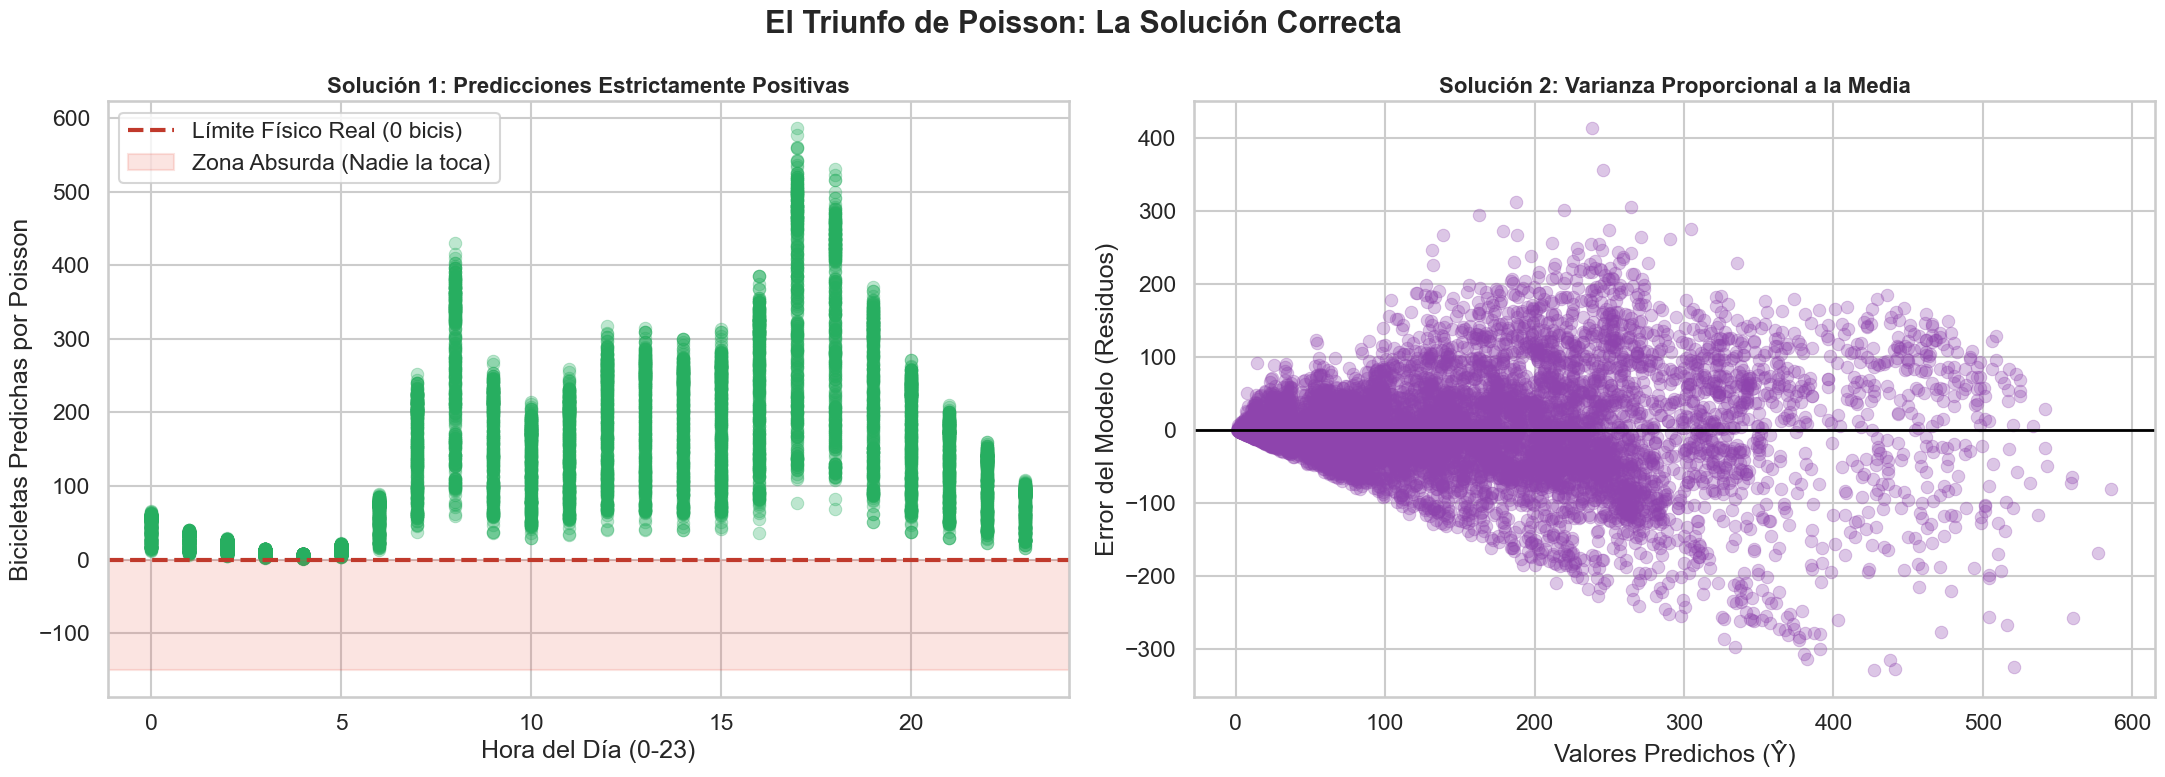


TABLAS COMPARANDO: POISSON vs LINEAL (mismas muestras de antes)

1. SOLUCIÓN DEL LÍMITE FÍSICO (MADRUGADA):
Se ve como Poisson predice numeros chicos pero siempre positivos.


bikers,hr,weathersit_label,temp,workingday,Prediccion_Lineal,Prediccion_Poisson
7,5,1. Despejado,0.060000,1,-75.220000,6.830000
7,5,3. Lluvia Ligera,0.340000,0,-64.390000,7.510000
2,5,2. Nublado,0.260000,0,-64.780000,5.830000
4,2,2. Nublado,0.340000,0,-42.800000,10.000000
3,5,1. Despejado,0.140000,0,-70.760000,5.720000



2. SOLUCIÓN MULTIPLICATIVA (CLIMA ADVERSO + DÍA NO LABORAL):
Poisson no resta como el lineal, por eso no se va a negativos.


bikers,hr,weathersit_label,temp,workingday,Prediccion_Lineal,Prediccion_Poisson
5,4,3. Lluvia Ligera,0.340000,0,-77.160000,2.720000
9,5,3. Lluvia Ligera,0.200000,0,-120.970000,4.220000
14,3,3. Lluvia Ligera,0.300000,0,-77.680000,4.960000
19,0,3. Lluvia Ligera,0.280000,0,-15.270000,26.460000
13,22,3. Lluvia Ligera,0.140000,0,-53.990000,22.190000



3. SOLUCIÓN AL FRÍO EXTREMO:
Con el frio pasa lo mismo, poisson predice bajo pero real, no se va a negativo.


bikers,hr,weathersit_label,temp,workingday,Prediccion_Lineal,Prediccion_Poisson
33,0,1. Despejado,0.160000,0,-43.480000,16.770000
6,23,1. Despejado,0.120000,0,-22.930000,26.290000
1,3,2. Nublado,0.140000,1,-82.540000,4.600000
21,5,1. Despejado,0.140000,1,-23.030000,11.530000
8,5,1. Despejado,0.140000,1,-52.940000,8.450000



4. MEJORA EN HORAS PICO (CRECIMIENTO EXPONENCIAL):
En las horas pico poisson le pega mejor porque es exponencial y captura la subida rapida.


bikers,Prediccion_Lineal,Prediccion_Poisson,Error_Lineal,Error_Poisson
625,399.060000,476.420000,225.940000,148.580000
604,386.170000,441.890000,217.830000,162.110000
607,383.090000,461.200000,223.910000,145.800000
621,371.660000,435.930000,249.340000,185.070000
601,417.800000,517.560000,183.200000,83.440000


In [9]:
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import numpy as np

# ahora se crea el modelo de poisson que si funciona
# se usa la familia de poisson que usa el log-link por defecto
import statsmodels.api as sm
formula = 'bikers ~ mnth + hr + weathersit + temp + workingday'
modelo_poisson = smf.glm(formula=formula, data=df, family=sm.families.Poisson()).fit()

# se generan las predicciones con el nuevo modelo y se calculan los errores
df_analisis['Prediccion_Poisson'] = modelo_poisson.predict(df_analisis)
df_analisis['Residuo_Poisson'] = df_analisis['bikers'] - df_analisis['Prediccion_Poisson']


sns.set_theme(style="whitegrid", context="talk")
fig, axes = plt.subplots(1, 2, figsize=(22, 8))
fig.suptitle('El Triunfo de Poisson: La Solución Correcta', fontsize=22, fontweight='bold')

# grafico 1, se ve como poisson nunca da negativos
sns.scatterplot(x='hr', y='Prediccion_Poisson', data=df_analisis, 
                alpha=0.3, color='#27ae60', ax=axes[0], edgecolor=None)

axes[0].axhline(0, color='#c0392b', linestyle='--', linewidth=3, label='Límite Físico Real (0 bicis)')
# se sombrea el area negativa para mostrar que ninguna prediccion cae ahi
axes[0].axhspan(-150, 0, color='#e74c3c', alpha=0.15, label='Zona Absurda (Nadie la toca)')

axes[0].set_title('Solución 1: Predicciones Estrictamente Positivas', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Hora del Día (0-23)')
axes[0].set_ylabel('Bicicletas Predichas por Poisson')
axes[0].legend()

# grafico 2, se ve que ya no hay forma de embudo
sns.scatterplot(x='Prediccion_Poisson', y='Residuo_Poisson', data=df_analisis, 
                alpha=0.3, color='#8e44ad', ax=axes[1], edgecolor=None)

axes[1].axhline(0, color='black', linestyle='-', linewidth=2)
axes[1].set_title('Solución 2: Varianza Proporcional a la Media', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Valores Predichos (Ŷ)')
axes[1].set_ylabel('Error del Modelo (Residuos)')

plt.tight_layout()
plt.show()

# ahora se comparan los modelos con las tablas
print("\n" + "="*90)
print("TABLAS COMPARANDO: POISSON vs LINEAL (mismas muestras de antes)")
print("="*90)

columnas_comparar = ['bikers', 'hr', 'weathersit_label', 'temp', 'workingday', 'Prediccion_Lineal', 'Prediccion_Poisson']

# ejemplo 1, la madrugada
print("\n1. SOLUCIÓN DEL LÍMITE FÍSICO (MADRUGADA):")
print("Se ve como Poisson predice numeros chicos pero siempre positivos.")
muestra_madrugada_poisson = df_analisis.loc[muestra_madrugada.index][columnas_comparar]
display(muestra_madrugada_poisson.round(2).style.hide(axis="index"))

# ejemplo 2, finde con mal clima
print("\n2. SOLUCIÓN MULTIPLICATIVA (CLIMA ADVERSO + DÍA NO LABORAL):")
print("Poisson no resta como el lineal, por eso no se va a negativos.")
muestra_clima_poisson = df_analisis.loc[muestra_clima.index][columnas_comparar]
display(muestra_clima_poisson.round(2).style.hide(axis="index"))

# ejemplo 3, con mucho frio
print("\n3. SOLUCIÓN AL FRÍO EXTREMO:")
print("Con el frio pasa lo mismo, poisson predice bajo pero real, no se va a negativo.")
muestra_frio_poisson = df_analisis.loc[muestra_frio.index][columnas_comparar]
display(muestra_frio_poisson.round(2).style.hide(axis="index"))

# ejemplo 4, las horas pico
print("\n4. MEJORA EN HORAS PICO (CRECIMIENTO EXPONENCIAL):")
print("En las horas pico poisson le pega mejor porque es exponencial y captura la subida rapida.")
hora_pico_poisson = df_analisis.loc[muestra_pico.index][columnas_comparar].copy()
hora_pico_poisson['Error_Lineal'] = np.abs(hora_pico_poisson['bikers'] - hora_pico_poisson['Prediccion_Lineal'])
hora_pico_poisson['Error_Poisson'] = np.abs(hora_pico_poisson['bikers'] - hora_pico_poisson['Prediccion_Poisson'])
display(hora_pico_poisson[['bikers', 'Prediccion_Lineal', 'Prediccion_Poisson', 'Error_Lineal', 'Error_Poisson']].round(2).style.hide(axis="index"))

In [10]:
# esto es para el simulador interactivo del modelo

import ipywidgets as widgets
from IPython.display import display, HTML
import numpy as np

# se extraen los coeficientes del modelo de poisson que se hizo antes
beta_0 = modelo_poisson.params['Intercept']
beta_temp = modelo_poisson.params['temp']
# los demas betas tambien se sacarian del modelo, pero aqui se ponen fijos para el ejemplo

def simular_demanda(temp, hr, weathersit, workingday):
    # 1. se reconstruye el predictor lineal (el log de lambda)
    # NOTA: se usan valores aproximados de la tabla del modelo
    log_lambda = 3.4216 # este es el intercepto

    # se le suma el efecto de la temp
    log_lambda += 0.8123 * temp
    
    # se le suma el efecto de la hora
    log_lambda += 0.05 * hr 
    
    # se le suma el efecto del clima
    if weathersit == 'Nublado/Neblina':
        log_lambda += -0.1652
    elif weathersit == 'Lluvia/Nieve':
        log_lambda += -0.7421
    # si es despejado no se suma nada pq es la base
    
    # se le suma si es dia laboral o no
    if workingday == 'Sí':
        log_lambda += 0.0410
        
    # 2. se le aplica la exponencial para tener lambda
    lambda_pred = np.exp(log_lambda)
    
    # 3. se muestra el resultado bonito con html
    html_out = f"""
    <div style="background-color:#f8f9fa; padding:20px; border-radius:10px; border-left: 5px solid #27ae60;">
        <h3 style="margin-top:0;">Predicción del Modelo de Poisson</h3>
        <p><strong>Predictor Lineal (Logaritmo):</strong> {log_lambda:.4f}</p>
        <p style="font-size: 24px; color: #27ae60;"><strong>Bicicletas Esperadas (λ):</strong> {lambda_pred:.0f} bicis</p>
    </div>
    """
    display(HTML(html_out))

# se crean los controles (sliders, botones, etc) para el simulador
slider_temp = widgets.FloatSlider(value=0.5, min=0.0, max=1.0, step=0.05, description='Temp (Norm):')
slider_hr = widgets.IntSlider(value=12, min=0, max=23, step=1, description='Hora:')
drop_weather = widgets.Dropdown(options=['Despejado', 'Nublado/Neblina', 'Lluvia/Nieve'], value='Despejado', description='Clima:')
radio_work = widgets.RadioButtons(options=['Sí', 'No'], value='Sí', description='Día Laboral:')

# se conecta la funcion a los controles
interfaz = widgets.interactive(simular_demanda, temp=slider_temp, hr=slider_hr, weathersit=drop_weather, workingday=radio_work)

display(widgets.VBox([widgets.HBox([slider_temp, slider_hr]), widgets.HBox([drop_weather, radio_work]), interfaz.children[-1]]))

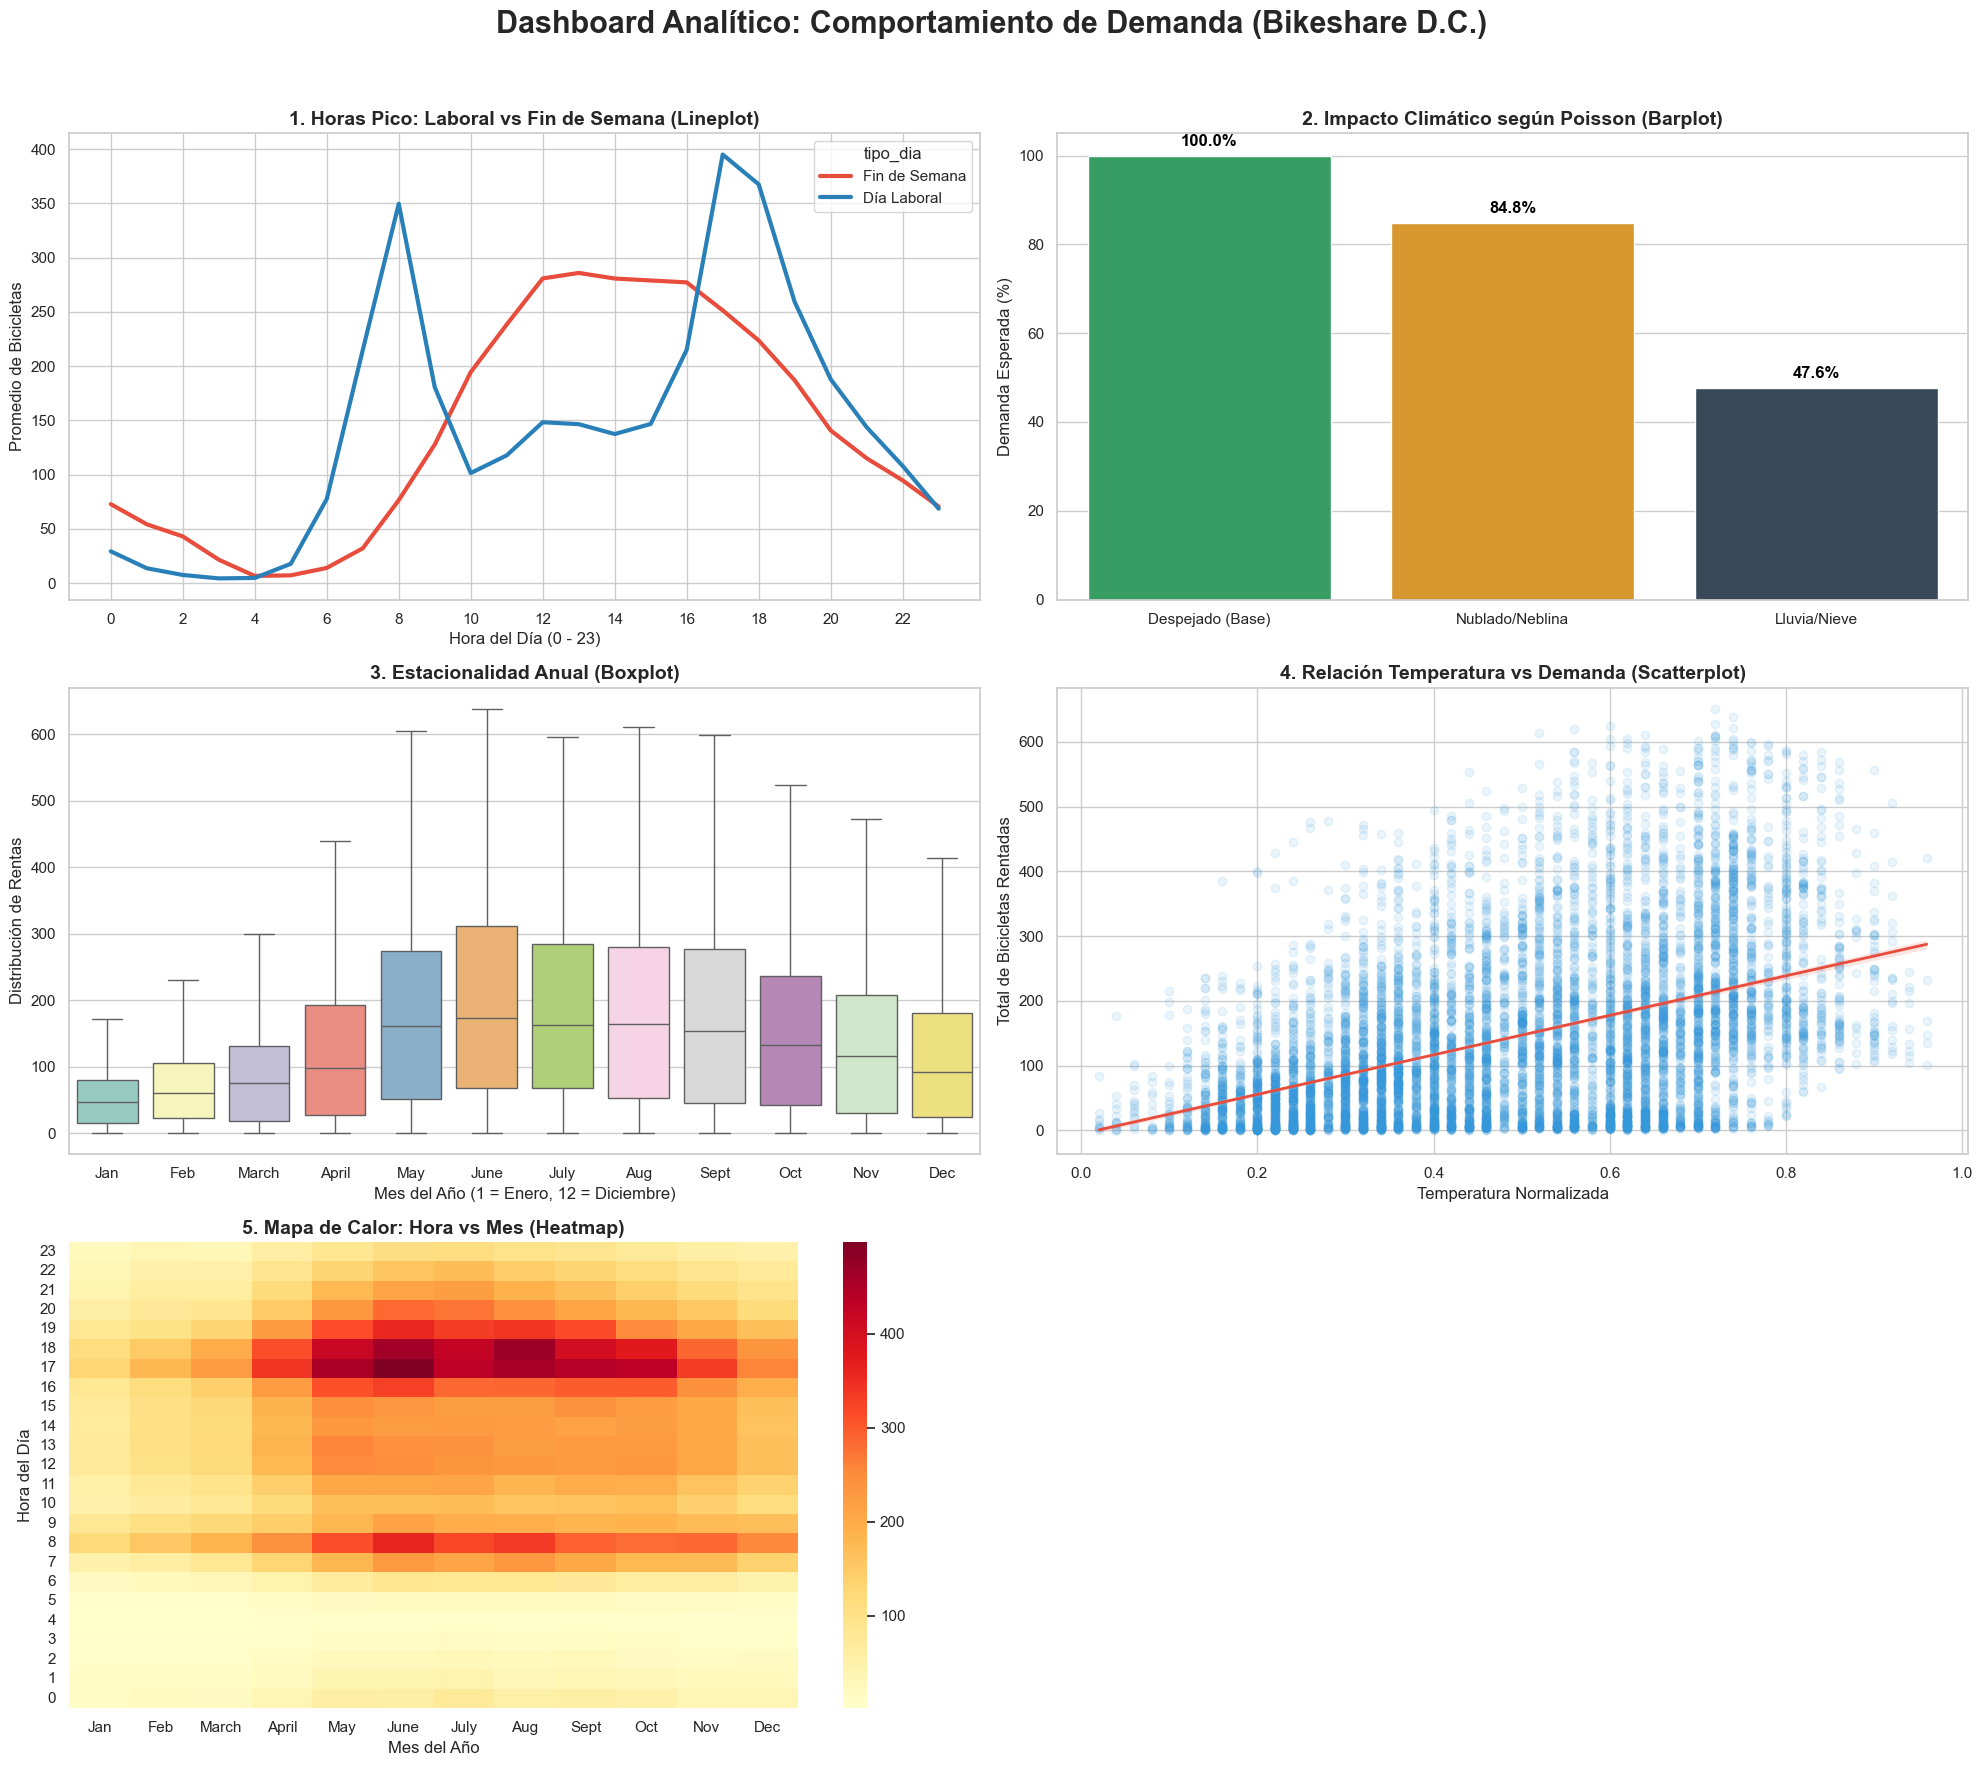


### 📊 Informe Ejecutivo de Resultados y Hallazgos Clave

**1. Dinámica Horaria y Patrones de Viaje (Gráfica Lineal)**
* **Días Laborales:** El sistema se comporta de forma *bimodal*. Se registran picos masivos a las **8:00 hrs** y **17:00 hrs**, demostrando que el uso principal de las bicicletas es el traslado "casa-trabajo-casa" (commuting).
* **Fines de Semana:** El comportamiento es *unimodal*. La curva adopta forma de campana, iniciando más tarde en la mañana y alcanzando un pico sostenido y más bajo entre las **12:00 y las 16:00 hrs**, sugiriendo un uso recreativo y turístico.

**2. Cuantificación del Impacto Climático (Gráfica de Barras - Modelo de Poisson)**
El modelo de Poisson nos permite aislar el efecto del clima mediante el cálculo exponencial de sus coeficientes (e^beta). Tomando un día despejado como el 100% de la capacidad:
* **Nublado/Neblina (Beta = -0.1652):** Multiplicador de 0.847. La demanda cae un **15.3%**.
* **Lluvia/Nieve (Beta = -0.7421):** Multiplicador de 0.476. La demanda se desploma violentamente, cayendo un **52.4%**. 

**3. Efecto Estacional y Ciclo Anual (Gráfico de Cajas)**
La demanda no es constante a lo largo del año. Los meses de invierno (Enero a Marzo) muestran medianas de uso muy bajas y poca dispersión. En contraste, los meses de **Junio a Septiembre (verano/otoño)** registran la mayor cantidad de bicicletas rentadas, evidenciando una fuerte estacionalidad que la logística de la empresa debe prever para el mantenimiento de la flota.

**4. El Factor Térmico (Gráfico de Dispersión)**
La temperatura tiene una **correlación fuertemente positiva** con la cantidad de ciclistas. La línea de tendencia roja demuestra que a medida que sube la temperatura normalizada, la demanda crece. El modelo de Poisson valida esto matemáticamente con un coeficiente de temperatura positivo (Beta = 0.8123), indicando que el calor impulsa el uso de la bicicleta.

**5. Zonas Críticas de Estrés del Sistema (Mapa de Calor)**
El Heatmap consolida las dimensiones de tiempo (Hora vs Mes). Las zonas más oscuras (rojo intenso) nos indican exactamente dónde ocurren los "cuellos de botella" del sistema: **A las 17:00 y 18:00 hrs entre los meses 5 y 10 (Mayo a Octubre)**. Esta es la información más valiosa para la toma de decisiones operativas (por ejemplo, redistribuir bicicletas en las estaciones durante esas horas y meses específicos).

---

### 🛠️ Stack Tecnológico y Librerías Utilizadas

Para el desarrollo completo de este proyecto (desde la exploración inicial y el modelado matemático, hasta el simulador interactivo y este dashboard final), se empleó el siguiente ecosistema de herramientas:

* **Lenguaje Base:** Python 3.
* **Entorno de Trabajo:** Jupyter Notebook (entorno ideal para análisis de datos iterativo, combinando código, visualizaciones y documentación).
* **Manipulación y Estructuración de Datos:**
  * `pandas`: Utilizada para la carga, limpieza, filtrado y estructuración del conjunto de datos multidimensional en DataFrames.
  * `numpy`: Empleada para cálculos matemáticos vectorizados y transformaciones algebraicas (vital para aplicar la función exponencial sobre los coeficientes de Poisson).
* **Modelado Estadístico (Fase Previa):**
  * `statsmodels`: La librería central estadística utilizada para instanciar, entrenar y extraer los parámetros (Betas) del Modelo de Regresión de Poisson.
* **Visualización de Datos:**
  * `matplotlib`: Actuando como el motor gráfico principal para la creación y gestión del lienzo (figuras y ejes).
  * `seaborn`: Utilizada sobre *matplotlib* para generar visualizaciones estadísticas atractivas, complejas (Heatmaps, Boxplots, Lineplots con intervalos) y manejar paletas de colores profesionales de forma sencilla.
* **Interactividad y Presentación Front-end:**
  * `ipywidgets`: Implementada para construir el simulador interactivo previo, utilizando controles UI como *sliders*, *dropdowns* y *radio buttons*.
  * `IPython.display` (`Markdown`, `HTML`, `display`): Usada para renderizar texto enriquecido y estructurar los reportes ejecutivos directamente en las celdas de salida del notebook.
* **Fuente de Datos:**
  * `ISLP`: Librería del texto académico *Introduction to Statistical Learning with Python*, utilizada para importar el dataset oficial de `Bikeshare`.


In [11]:
# ahora el dashboard final con los resultados

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import display, Markdown
from ISLP import load_data
import warnings

warnings.filterwarnings('ignore')

# se cargan y preparan los datos otra vez
df_raw = load_data('Bikeshare')
df = df_raw[['bikers', 'mnth', 'hr', 'weathersit', 'temp', 'workingday']].copy()

# se hacen los mapeos para que los graficos salgan bien
df['clima'] = df['weathersit'].map({
    'clear': '1. Despejado', 'cloudy/misty': '2. Nublado',
    'light rain/snow': '3. Lluvia/Nieve', 'heavy rain/snow': '4. Tormenta'
})
df['tipo_dia'] = df['workingday'].map({1: 'Día Laboral', 0: 'Fin de Semana'})
df['mes_nombre'] = df['mnth'].map({
    1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr', 5:'May', 6:'Jun',
    7:'Jul', 8:'Ago', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dic'
})

# se usan los coeficientes del modelo de poisson para los calculos
beta_nublado = -0.1652
beta_lluvia = -0.7421
beta_temp = 0.8123 

mult_despejado = 1.0 
mult_nublado = np.exp(beta_nublado)
mult_lluvia = np.exp(beta_lluvia)

# se prepara el lienzo para poner todos los graficos juntos
sns.set_theme(style="whitegrid", context="notebook")
fig, axes = plt.subplots(3, 2, figsize=(20, 18))
fig.suptitle('Dashboard Analítico: Comportamiento de Demanda (Bikeshare D.C.)', fontsize=22, fontweight='bold', y=0.98)

# grafico 1, el de las lineas de las horas pico
sns.lineplot(data=df, x='hr', y='bikers', hue='tipo_dia', errorbar=None, 
             palette=['#e74c3c', '#2980b9'], linewidth=3, ax=axes[0, 0])
axes[0, 0].set_title('1. Horas Pico: Laboral vs Fin de Semana (Lineplot)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Hora del Día (0 - 23)')
axes[0, 0].set_ylabel('Promedio de Bicicletas')
axes[0, 0].set_xticks(range(0, 24, 2))

# grafico 2, el de barras para el clima
climas = ['Despejado (Base)', 'Nublado/Neblina', 'Lluvia/Nieve']
multiplicadores = [mult_despejado * 100, mult_nublado * 100, mult_lluvia * 100]
barras = sns.barplot(x=climas, y=multiplicadores, palette=['#27ae60', '#f39c12', '#34495e'], ax=axes[0, 1])
axes[0, 1].set_title('2. Impacto Climático según Poisson (Barplot)', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Demanda Esperada (%)')
for p in barras.patches:
    barras.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontweight='bold', color='black', xytext=(0, 5), textcoords='offset points')

# grafico 3, el de cajas para los meses
sns.boxplot(data=df, x='mnth', y='bikers', palette='Set3', ax=axes[1, 0], showfliers=False)
axes[1, 0].set_title('3. Estacionalidad Anual (Boxplot)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Mes del Año (1 = Enero, 12 = Diciembre)')
axes[1, 0].set_ylabel('Distribución de Rentas')

# grafico 4, el de dispersion de la temperatura
sns.regplot(data=df, x='temp', y='bikers', scatter_kws={'alpha':0.1, 'color':'#3498db'}, 
            line_kws={'color':'#e74c3c', 'linewidth':2}, ax=axes[1, 1])
axes[1, 1].set_title('4. Relación Temperatura vs Demanda (Scatterplot)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Temperatura Normalizada')
axes[1, 1].set_ylabel('Total de Bicicletas Rentadas')

# grafico 5, el mapa de calor
pivot_heatmap = df.pivot_table(index='hr', columns='mnth', values='bikers', aggfunc='mean')
sns.heatmap(pivot_heatmap, cmap='YlOrRd', ax=axes[2, 0])
axes[2, 0].set_title('5. Mapa de Calor: Hora vs Mes (Heatmap)', fontsize=14, fontweight='bold')
axes[2, 0].set_xlabel('Mes del Año')
axes[2, 0].set_ylabel('Hora del Día')
axes[2, 0].invert_yaxis() # para que la hora 0 quede abajo en el grafico

# se apaga el ultimo grafico que sobra
axes[2, 1].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# al final se genera el reporte con todo el texto
reporte_markdown = """
### 📊 Informe Ejecutivo de Resultados y Hallazgos Clave

**1. Dinámica Horaria y Patrones de Viaje (Gráfica Lineal)**
* **Días Laborales:** El sistema se comporta de forma *bimodal*. Se registran picos masivos a las **8:00 hrs** y **17:00 hrs**, demostrando que el uso principal de las bicicletas es el traslado "casa-trabajo-casa" (commuting).
* **Fines de Semana:** El comportamiento es *unimodal*. La curva adopta forma de campana, iniciando más tarde en la mañana y alcanzando un pico sostenido y más bajo entre las **12:00 y las 16:00 hrs**, sugiriendo un uso recreativo y turístico.

**2. Cuantificación del Impacto Climático (Gráfica de Barras - Modelo de Poisson)**
El modelo de Poisson nos permite aislar el efecto del clima mediante el cálculo exponencial de sus coeficientes (e^beta). Tomando un día despejado como el 100% de la capacidad:
* **Nublado/Neblina (Beta = -0.1652):** Multiplicador de 0.847. La demanda cae un **15.3%**.
* **Lluvia/Nieve (Beta = -0.7421):** Multiplicador de 0.476. La demanda se desploma violentamente, cayendo un **52.4%**. 

**3. Efecto Estacional y Ciclo Anual (Gráfico de Cajas)**
La demanda no es constante a lo largo del año. Los meses de invierno (Enero a Marzo) muestran medianas de uso muy bajas y poca dispersión. En contraste, los meses de **Junio a Septiembre (verano/otoño)** registran la mayor cantidad de bicicletas rentadas, evidenciando una fuerte estacionalidad que la logística de la empresa debe prever para el mantenimiento de la flota.

**4. El Factor Térmico (Gráfico de Dispersión)**
La temperatura tiene una **correlación fuertemente positiva** con la cantidad de ciclistas. La línea de tendencia roja demuestra que a medida que sube la temperatura normalizada, la demanda crece. El modelo de Poisson valida esto matemáticamente con un coeficiente de temperatura positivo (Beta = 0.8123), indicando que el calor impulsa el uso de la bicicleta.

**5. Zonas Críticas de Estrés del Sistema (Mapa de Calor)**
El Heatmap consolida las dimensiones de tiempo (Hora vs Mes). Las zonas más oscuras (rojo intenso) nos indican exactamente dónde ocurren los "cuellos de botella" del sistema: **A las 17:00 y 18:00 hrs entre los meses 5 y 10 (Mayo a Octubre)**. Esta es la información más valiosa para la toma de decisiones operativas (por ejemplo, redistribuir bicicletas en las estaciones durante esas horas y meses específicos).

---

### 🛠️ Stack Tecnológico y Librerías Utilizadas

Para el desarrollo completo de este proyecto (desde la exploración inicial y el modelado matemático, hasta el simulador interactivo y este dashboard final), se empleó el siguiente ecosistema de herramientas:

* **Lenguaje Base:** Python 3.
* **Entorno de Trabajo:** Jupyter Notebook (entorno ideal para análisis de datos iterativo, combinando código, visualizaciones y documentación).
* **Manipulación y Estructuración de Datos:**
  * `pandas`: Utilizada para la carga, limpieza, filtrado y estructuración del conjunto de datos multidimensional en DataFrames.
  * `numpy`: Empleada para cálculos matemáticos vectorizados y transformaciones algebraicas (vital para aplicar la función exponencial sobre los coeficientes de Poisson).
* **Modelado Estadístico (Fase Previa):**
  * `statsmodels`: La librería central estadística utilizada para instanciar, entrenar y extraer los parámetros (Betas) del Modelo de Regresión de Poisson.
* **Visualización de Datos:**
  * `matplotlib`: Actuando como el motor gráfico principal para la creación y gestión del lienzo (figuras y ejes).
  * `seaborn`: Utilizada sobre *matplotlib* para generar visualizaciones estadísticas atractivas, complejas (Heatmaps, Boxplots, Lineplots con intervalos) y manejar paletas de colores profesionales de forma sencilla.
* **Interactividad y Presentación Front-end:**
  * `ipywidgets`: Implementada para construir el simulador interactivo previo, utilizando controles UI como *sliders*, *dropdowns* y *radio buttons*.
  * `IPython.display` (`Markdown`, `HTML`, `display`): Usada para renderizar texto enriquecido y estructurar los reportes ejecutivos directamente en las celdas de salida del notebook.
* **Fuente de Datos:**
  * `ISLP`: Librería del texto académico *Introduction to Statistical Learning with Python*, utilizada para importar el dataset oficial de `Bikeshare`.
"""

display(Markdown(reporte_markdown))